# 08 — `src/models/xgb_ordinal.py`: The Primary Model

This is the model CLAUDE.md names as the default choice, and the one that ended up winning the Days 4-7 comparison against the rule baseline and the LSTM. This notebook explains the central trick that makes plain XGBoost ordinal-aware: **regression + tuned threshold binning**, instead of the more obvious "5-class classifier" approach.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))  # add project root to path so `src` package imports resolve from a notebook in notebooks/

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb

from src.models import xgb_ordinal
from src.data.feature_engineering import FEATURE_COLUMNS
from src.config import PROCESSED_DIR, SEVERITY_TIERS, N_TIERS

## Why regression, not `multi:softmax` classification

This is the single most important idea in this file, so it's worth being very explicit about it.

**The obvious approach** would be `xgb.XGBClassifier(objective="multi:softmax", num_class=5)` — treat this as an ordinary 5-category classification problem. But to that loss function, the 5 tiers are just unrelated labels. Predicting "Normal" when the truth is "HACE risk" is scored exactly as wrong as predicting "Mild AMS" when the truth is "Severe AMS" — both are simply "not the right one of 5 categories." That throws away the entire point of the data being *ordinal* (see the `config.py` notebook).

**The approach actually used here**: train XGBoost as a **regressor**, with the target being the severity index itself as a continuous number (0.0 for Normal, ..., 4.0 for HACE risk). Now the loss function inherently understands distance: predicting 3.7 when the truth is 4 (HACE risk) is a small squared error; predicting 0.2 is a huge one. The model is incentivized to get *close*, not just exactly right — which is precisely the ordinal property we want.

The catch: a regressor outputs a continuous number like `2.31`, not a discrete tier. So after training, we need to convert that back into one of the 5 tiers — that's what `bin_predictions()` and `tune_thresholds()` do below.

In [2]:
# A minimal illustration of the core idea, decoupled from the real dataset:
# regression loss vs classification loss on the SAME two wrong predictions.
true_tier = 4  # HACE risk

pred_close = 3.7   # regression: "almost 4"
pred_far = 0.2      # regression: "way off"

print("Regression squared error:")
print(f"  close miss (pred=3.7): {(pred_close - true_tier)**2:.2f}")
print(f"  far miss   (pred=0.2): {(pred_far - true_tier)**2:.2f}")
print("  -> the loss function ITSELF penalizes the far miss much more heavily\n")

print("Plain multi-class 'is it exactly right' loss:")
print(f"  close miss (predicted tier 4 rounds from 3.7... but a raw classifier would've predicted class 3 or 4 as a LABEL, not a number): wrong = 1")
print(f"  far miss   (predicted tier 0): wrong = 1")
print("  -> to a plain classifier, BOTH mistakes just count as 'wrong', equally")

Regression squared error:
  close miss (pred=3.7): 0.09
  far miss   (pred=0.2): 14.44
  -> the loss function ITSELF penalizes the far miss much more heavily

Plain multi-class 'is it exactly right' loss:
  close miss (predicted tier 4 rounds from 3.7... but a raw classifier would've predicted class 3 or 4 as a LABEL, not a number): wrong = 1
  far miss   (predicted tier 0): wrong = 1
  -> to a plain classifier, BOTH mistakes just count as 'wrong', equally


## Class weighting: still handling imbalance, just from the regression side

```python
sample_weight = compute_sample_weight("balanced", y_train.round().astype(int))
```

Even though we're training a regressor, class imbalance (CLAUDE.md's "Normal will dominate") still needs to be addressed — otherwise the regressor would minimize overall squared error mostly by getting the abundant "Normal" rows right and barely bothering with the rare HACE-risk rows, since they contribute so little to the total loss by sheer numeric weight. `compute_sample_weight("balanced", ...)` assigns each training row a weight inversely proportional to how common its (rounded-to-nearest-integer) class is — rare classes get proportionally larger per-row weight, forcing the regressor to care about getting them right too. This is computed **only from the training split's label distribution** — never peeking at validation or test distributions, which would be a form of leakage.

In [3]:
train_df = pd.read_csv(PROCESSED_DIR / "train.csv")
val_df = pd.read_csv(PROCESSED_DIR / "val.csv")
test_df = pd.read_csv(PROCESSED_DIR / "test.csv")

from sklearn.utils.class_weight import compute_sample_weight
y_train_int = train_df["severity_index"].astype(int)
sample_weight = compute_sample_weight("balanced", y_train_int)  # weight = n_samples / (n_classes * class_count) per row, so rare classes get proportionally larger weight

weight_by_class = pd.Series(sample_weight, index=y_train_int).groupby(level=0).first()  # one representative weight per class (all rows of a class share the same weight)
print("Per-row sample weight assigned to each class (train split):")
for idx, tier in enumerate(SEVERITY_TIERS):
    n = (y_train_int == idx).sum()
    print(f"  {tier:12s} (n={n:>7,}):  weight={weight_by_class.get(idx, 0):.3f}")
print("\nNotice: rarer classes get a LARGER per-row weight, compensating for having fewer rows.")

Per-row sample weight assigned to each class (train split):
  Normal       (n=891,000):  weight=0.337
  Mild AMS     (n=253,800):  weight=1.183
  Severe AMS   (n=199,800):  weight=1.503
  HAPE risk    (n= 86,400):  weight=3.475
  HACE risk    (n= 70,200):  weight=4.277

Notice: rarer classes get a LARGER per-row weight, compensating for having fewer rows.


## Training: `train()`

```python
model = xgb.XGBRegressor(
    n_estimators=300, max_depth=5, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    objective="reg:squarederror", random_state=RANDOM_SEED,
    early_stopping_rounds=20, eval_metric="mae",
)
model.fit(X_train, y_train, sample_weight=sample_weight, eval_set=[(X_val, y_val)], verbose=False)
```

A few hyperparameter choices worth understanding, not just accepting as magic numbers:
- **`subsample=0.8`, `colsample_bytree=0.8`**: each tree only sees 80% of rows and 80% of features, chosen randomly. This is a standard overfitting guard for gradient boosting — if every tree saw 100% of the same data every time, the ensemble could latch onto noise-specific patterns in the training set.
- **`early_stopping_rounds=20`**: training stops once 20 rounds pass without the *validation* MAE improving, and keeps the best-performing iteration rather than whatever the last one happened to be. This is what actually prevents the model from continuing to fit the training set past the point it's still generalizing.
- **`eval_metric="mae"`** (mean absolute error): chosen to watch during training because it's on the same scale as our end goal (mean absolute tier error) — MAE and MATE are the same underlying quantity, just MAE is on the continuous regression output and MATE is on the binned discrete predictions.

Let's actually run training now, on the real data.

In [4]:
print("Training XGBoost ordinal regressor on the real train/val split...")
model, thresholds = xgb_ordinal.train(train_df, val_df)  # trains with default n_estimators=300, max_depth=5, learning_rate=0.05 (see xgb_ordinal.train's signature), then tunes tier thresholds on val
print("Done.")
print(f"Tuned thresholds: {[round(t, 3) for t in thresholds]}")

Training XGBoost ordinal regressor on the real train/val split...


Done.
Tuned thresholds: [0.85, 2.0, 2.85, 4.0]


## What the raw regression output looks like, before binning

Before we look at `bin_predictions()`, let's see what the model's raw continuous predictions actually look like against the true (discrete) tiers — this is the "before" picture that `bin_predictions()` and `tune_thresholds()` operate on.

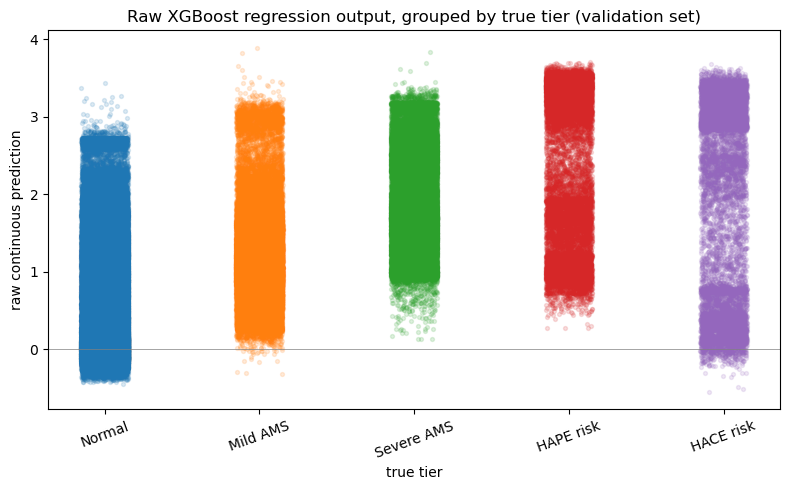

In [5]:
val_continuous = model.predict(val_df[FEATURE_COLUMNS])  # raw continuous severity scores (not yet binned into discrete tiers)
y_val_true = val_df["severity_index"].to_numpy()

fig, ax = plt.subplots(figsize=(8, 5))
for tier_idx, tier in enumerate(SEVERITY_TIERS):
    mask = y_val_true == tier_idx
    ax.scatter(np.full(mask.sum(), tier_idx) + np.random.uniform(-0.15, 0.15, mask.sum()),  # jitter x-position randomly so overlapping points at the same true tier are visible instead of stacking exactly
               val_continuous[mask], alpha=0.15, s=8, label=tier)
ax.set_xticks(range(N_TIERS), SEVERITY_TIERS, rotation=20)
ax.set_xlabel("true tier")
ax.set_ylabel("raw continuous prediction")
ax.set_title("Raw XGBoost regression output, grouped by true tier (validation set)")
ax.axhline(0, color="gray", linewidth=0.5)
plt.tight_layout()
plt.show()

Ideally you'd see the continuous predictions trend upward as the true tier increases (even if noisy/overlapping) — that upward trend is what confirms the regressor is genuinely learning the ordinal relationship, not just noise.

## `bin_predictions()`: continuous → discrete

```python
def bin_predictions(continuous_preds, thresholds):
    assert len(thresholds) == N_TIERS - 1
    return np.digitize(continuous_preds, thresholds).clip(0, N_TIERS - 1)
```

With 5 tiers we need exactly 4 cut points to divide the continuous number line into 5 buckets. `np.digitize` does exactly this: given `thresholds=[0.5, 1.5, 2.5, 3.5]`, a prediction of `0.3` falls in bucket 0 (below 0.5), a prediction of `2.1` falls in bucket 2 (between 1.5 and 2.5), etc. The naive choice of thresholds is just `[0.5, 1.5, 2.5, 3.5]` — equivalent to simple rounding — and that's the starting point `tune_thresholds()` searches from.

In [6]:
naive_thresholds = [0.5, 1.5, 2.5, 3.5]  # naive rounding cut points -- the starting point tune_thresholds() searches outward from
example_continuous = np.array([-0.2, 0.4, 0.9, 1.6, 2.3, 2.6, 3.9, 4.5])
binned = xgb_ordinal.bin_predictions(example_continuous, naive_thresholds)  # np.digitize under the hood, clipped to valid tier range

for cont, tier_idx in zip(example_continuous, binned):
    print(f"  continuous={cont:>5.1f}  ->  tier {tier_idx} ({SEVERITY_TIERS[tier_idx]})")

  continuous= -0.2  ->  tier 0 (Normal)
  continuous=  0.4  ->  tier 0 (Normal)
  continuous=  0.9  ->  tier 1 (Mild AMS)
  continuous=  1.6  ->  tier 2 (Severe AMS)
  continuous=  2.3  ->  tier 2 (Severe AMS)
  continuous=  2.6  ->  tier 3 (HAPE risk)
  continuous=  3.9  ->  tier 4 (HACE risk)
  continuous=  4.5  ->  tier 4 (HACE risk)


## `tune_thresholds()`: why not just round?

```python
def tune_thresholds(y_val_true, val_continuous_preds):
    best_thresholds = [0.5, 1.5, 2.5, 3.5]
    ...
    candidate_offsets = np.arange(-0.4, 0.41, 0.05)
    for _ in range(3):
        for i in range(len(best_thresholds)):
            for offset in candidate_offsets:
                trial = list(best_thresholds)
                trial[i] += offset
                ... # keep monotonic
                if mate(trial) < best_mate: keep it
```

Naive rounding (equivalent to the `[0.5, 1.5, 2.5, 3.5]` starting point) implicitly assumes each tier's predictions are symmetric around its center. But that's not guaranteed — if the model, because of class imbalance, systematically *under-predicts* severity for the rare HACE-risk class (predicting values like 3.2 for true HACE cases instead of centering around 4.0), then shifting that boundary threshold down would catch more true positives instead of losing them all to "close but rounds down."

This is a **coordinate-descent search**: instead of jointly searching all 4 thresholds at once (which would be a much larger search space), it adjusts one threshold at a time, testing small offsets, keeping any change that improves Mean Absolute Tier Error on the *validation* set (never test — that would be leakage), and repeats a few passes until it converges. The monotonic constraint (`trial[i] > trial[i-1]` etc.) exists because `np.digitize` requires ascending thresholds — otherwise the bucket ordering breaks.

In [7]:
print("Naive (rounding) thresholds:  [0.5, 1.5, 2.5, 3.5]")
print("Tuned thresholds (this run):  ", [round(t, 3) for t in thresholds])
print()

naive_val_pred = xgb_ordinal.bin_predictions(val_continuous, [0.5, 1.5, 2.5, 3.5])
tuned_val_pred = xgb_ordinal.bin_predictions(val_continuous, thresholds)

naive_mate = np.mean(np.abs(naive_val_pred - y_val_true))  # mean absolute tier error using naive rounding thresholds
tuned_mate = np.mean(np.abs(tuned_val_pred - y_val_true))  # mean absolute tier error using tune_thresholds()'s searched cut points
print(f"Validation MATE with naive thresholds: {naive_mate:.4f}")
print(f"Validation MATE with tuned thresholds: {tuned_mate:.4f}")
print(f"(tuning should be <= naive, since it's a strict search improvement over the same starting point)")

Naive (rounding) thresholds:  [0.5, 1.5, 2.5, 3.5]
Tuned thresholds (this run):   [0.85, 2.0, 2.85, 4.0]

Validation MATE with naive thresholds: 0.5552
Validation MATE with tuned thresholds: 0.4629
(tuning should be <= naive, since it's a strict search improvement over the same starting point)


## Evaluating on the real held-out test set

In [8]:
from src.models.metrics import evaluate, print_report

y_pred = xgb_ordinal.predict(model, thresholds, test_df)  # model.predict() (continuous) + bin_predictions() (tiers), combined
y_true = test_df["severity_index"].to_numpy()
result = evaluate(y_true, y_pred, model_name="XGBoost Ordinal (test set)")
print_report(result)


  XGBoost Ordinal (test set)
  Precision (macro):       0.3873
  Recall (macro):          0.4046
  F1 (macro):              0.3742
  Mean Abs Tier Error:     0.5942  (0 = perfect)
  Under-triage rate:       0.2208  (predicted too mild)

  Confusion matrix (rows=actual, cols=predicted):
            Normal  Mild AMS  Severe AMS  HAPE risk  HACE risk
Normal      125845     64316        9169        470          0
Mild AMS     12082     42162        5022        134          0
Severe AMS    4614     24729       17166       2091          0
HAPE risk     2887      7373        4206       7134          0
HACE risk     2958      5246        2515      10881          0



## Feature importances — a sanity check, not just a nice-to-have

```python
importances = pd.Series(model.feature_importances_, index=FEATURE_COLUMNS).sort_values(ascending=False)
```

This matters for more than curiosity: it's a check that the model is leaning on *clinically sensible* signals rather than something spurious. If `hr` (raw heart rate, no altitude context) dominated over `spo2_delta` (the altitude-adjusted deviation `docs/lls_mapping.md` centers its entire reasoning on), that would be a red flag worth investigating before trusting the model at all.

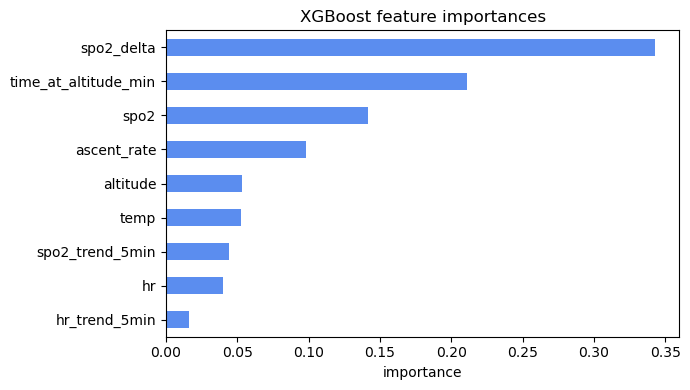

spo2_delta              0.3428
time_at_altitude_min    0.2113
spo2                    0.1418
ascent_rate             0.0979
altitude                0.0532
temp                    0.0530
spo2_trend_5min         0.0440
hr                      0.0402
hr_trend_5min           0.0159
dtype: float32


In [9]:
importances = pd.Series(model.feature_importances_, index=FEATURE_COLUMNS).sort_values(ascending=False)  # how much each feature contributed to the trees' splits, ranked descending

fig, ax = plt.subplots(figsize=(7, 4))
importances.plot(kind="barh", ax=ax, color="#5B8DEF")
ax.set_xlabel("importance")
ax.set_title("XGBoost feature importances")
ax.invert_yaxis()  # so the highest-importance feature appears at the TOP of the horizontal bar chart, matching the sorted order above
plt.tight_layout()
plt.show()
print(importances.round(4))

As expected, `spo2_delta` and `time_at_altitude_min` should dominate — matching `docs/lls_mapping.md`'s clinical reasoning that deviation-from-altitude-expected SpO2 and cumulative exposure time are what actually matter, not any single instantaneous reading in isolation.

## Saving and loading

```python
def save(model, thresholds):
    model.save_model(str(MODEL_PATH))          # XGBoost's native JSON format
    json.dump({"thresholds": thresholds, "feature_columns": FEATURE_COLUMNS}, ...)

def load():
    model = xgb.XGBRegressor()
    model.load_model(str(MODEL_PATH))
    ...
```

Two files get saved: the model itself (XGBoost's native serialization), and a small metadata JSON with the tuned thresholds *and* the exact list of feature columns the model expects, in order. Saving `feature_columns` alongside the model — not just relying on `FEATURE_COLUMNS` still being correct in the code later — means that even if `feature_engineering.py`'s feature list changes in the future, this saved model's metadata still records exactly what it was actually trained on.

## Summary

The core trick: train XGBoost as a **regressor** on the severity index (so the loss function itself understands tier ordering), then convert the continuous output back to discrete tiers using thresholds **tuned on the validation set** to minimize Mean Absolute Tier Error — rather than naive rounding, which assumes a symmetry the data doesn't guarantee. Combined with balanced sample weighting for the class imbalance, this is what let XGBoost win the Days 4-7 model comparison against both the rule baseline and the LSTM.

**Next notebook:** `09_lstm_model.ipynb` — the deep-learning comparison model, and why it took a different (classification, not regression) approach to the same ordinal problem.